In [1]:
import pandas as pd
import numpy as np

# Load Pima Indians Diabetes dataset from public repository
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
pima_df = pd.read_csv(url, header=None, names=columns)

print("Dataset Shape (rows, cols):", pima_df.shape)
print("\nFirst 3 rows of raw dataset:")
print(pima_df.head(3))

# Count invalid zero values in features where a zero is physiologically impossible
zero_counts = (pima_df[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).sum()
print("\nInvalid Zero Values per column:\n", zero_counts)


Dataset Shape (rows, cols): (768, 9)

First 3 rows of raw dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  

Invalid Zero Values per column:
 Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [2]:
from sklearn.impute import SimpleImputer

# Replace invalid zero values with NaN
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
pima_df[cols_to_impute] = pima_df[cols_to_impute].replace(0, np.nan)

print("Missing values after marking zeros:\n", pima_df.isnull().sum())

# Apply median imputation to replace NaN values
imputer = SimpleImputer(strategy='median')
pima_df[cols_to_impute] = imputer.fit_transform(pima_df[cols_to_impute])

print("\nMissing values after statistical median imputation:\n", pima_df.isnull().sum())


Missing values after marking zeros:
 Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

Missing values after statistical median imputation:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [3]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

features = columns[:-1]
X = pima_df[features]

# Apply MinMaxScaler (Normalization)
min_max_scaler = MinMaxScaler()
X_normalized = min_max_scaler.fit_transform(X)
print("Normalized Range Boundaries (Min/Max):", X_normalized.min(), "to", X_normalized.max())

# Apply StandardScaler (Standardization)
standard_scaler = StandardScaler()
X_standardized = standard_scaler.fit_transform(X)
print("Standardized Mean (approx 0):", round(X_standardized.mean(), 4))
print("Standardized Std Dev (approx 1):", round(X_standardized.std(), 4))


Normalized Range Boundaries (Min/Max): 0.0 to 1.0000000000000002
Standardized Mean (approx 0): 0.0
Standardized Std Dev (approx 1): 1.0


In [4]:
from sklearn.preprocessing import PowerTransformer

# Evaluate raw skewness of the Insulin column
original_skew = pima_df['Insulin'].skew()
print("Original skewness coefficient of 'Insulin':", round(original_skew, 4))

# Apply Yeo-Johnson transformation to stabilize variance
power_transformer = PowerTransformer(method='yeo-johnson')
insulin_transformed = power_transformer.fit_transform(pima_df[['Insulin']])

# Check the new skewness coefficient
transformed_skew = pd.Series(insulin_transformed.flatten()).skew()
print("Skewness coefficient after Power Transformation:", round(transformed_skew, 4))


Original skewness coefficient of 'Insulin': 3.38
Skewness coefficient after Power Transformation: 0.0276


In [5]:
# Create preprocessed DataFrame combining standardized features and outcomes
processed_pima_df = pd.DataFrame(data=X_standardized, columns=features)
processed_pima_df['Outcome'] = pima_df['Outcome']

# Export to system directory
processed_pima_df.to_csv("processed_pima_diabetes.csv", index=False)
print("Processed Pima dataset exported successfully to 'processed_pima_diabetes.csv'. Shape:", processed_pima_df.shape)


Processed Pima dataset exported successfully to 'processed_pima_diabetes.csv'. Shape: (768, 9)


In [6]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load Sonar dataset
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"
sonar_features = [f"F_{i}" for i in range(1, 61)]
sonar_columns = sonar_features + ['Class']
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

# Encode class: M (Mine) -> 1, R (Rock) -> 0
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

X_sonar = sonar_df[sonar_features]

# Scale features
scaler = StandardScaler()
X_sonar_scaled = scaler.fit_transform(X_sonar)

print("Standardized features shape:", X_sonar_scaled.shape)


Standardized features shape: (208, 60)


In [7]:
from sklearn.decomposition import PCA

# Apply PCA to preserve 90% of total variance
pca_90 = PCA(n_components=0.90, random_state=42)
X_pca_90 = pca_90.fit_transform(X_sonar_scaled)

print("Original dimensions count:", X_sonar_scaled.shape[1])
print("Reduced dimensions count (to preserve 90% variance):", X_pca_90.shape[1])


Original dimensions count: 60
Reduced dimensions count (to preserve 90% variance): 22


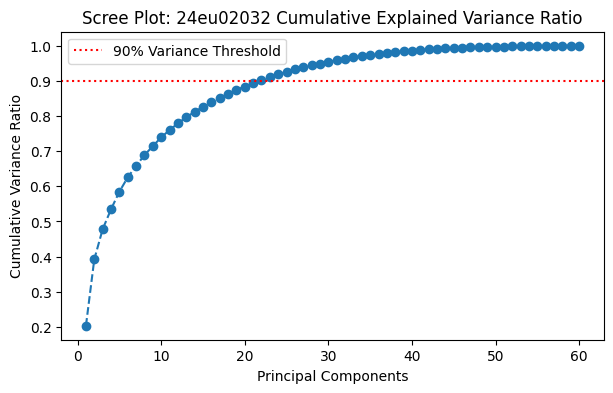

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Fit full PCA to compute complete variance ratios
pca_full = PCA(random_state=42)
pca_full.fit(X_sonar_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot Cumulative Explained Variance
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Variance Threshold')
plt.title("Scree Plot: 24eu02032 Cumulative Explained Variance Ratio")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance Ratio")
plt.legend()
plt.show()


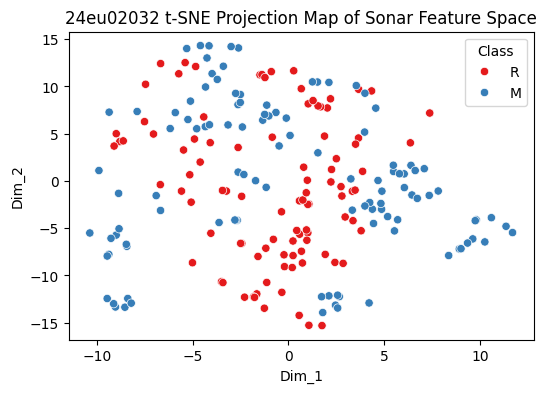

In [10]:
from sklearn.manifold import TSNE
import seaborn as sns

# Project standardized features onto a 2D space using t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_sonar_scaled)

# Construct visualization DataFrame
tsne_df = pd.DataFrame(X_tsne, columns=['Dim_1', 'Dim_2'])
tsne_df['Class'] = sonar_df['Class']

# Plot t-SNE clusters
plt.figure(figsize=(6, 4))
sns.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2', hue='Class', palette='Set1')
plt.title("24eu02032 t-SNE Projection Map of Sonar Feature Space")
plt.show()


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Evaluate performance on all 60 scaled raw features
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_sonar_scaled, sonar_df['Class_numeric'], test_size=0.3, random_state=42)
lr_raw = LogisticRegression()
lr_raw.fit(X_train_raw, y_train)
acc_raw = accuracy_score(y_test, lr_raw.predict(X_test_raw))

# Evaluate performance on the reduced PCA components
X_train_pca, X_test_pca, _, _ = train_test_split(X_pca_90, sonar_df['Class_numeric'], test_size=0.3, random_state=42)
lr_pca = LogisticRegression()
lr_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, lr_pca.predict(X_test_pca))

print(f"Accuracy using all 60 scaled features: {acc_raw * 100:.2f}%")
print(f"Accuracy using {X_pca_90.shape[1]} PCA components:  {acc_pca * 100:.2f}%")


Accuracy using all 60 scaled features: 76.19%
Accuracy using 22 PCA components:  87.30%


In [12]:
from sklearn.feature_selection import SelectKBest, f_classif

# Rank and select the top 4 features using SelectKBest (ANOVA F-value)
selector = SelectKBest(score_func=f_classif, k=4)
selector.fit(X_standardized, pima_df['Outcome'])

# Build a summary DataFrame of feature scores
anova_scores = pd.DataFrame({'Feature': features, 'F-Score': selector.scores_}).sort_values(by='F-Score', ascending=False)
print("ANOVA F-Test Scores:\n", anova_scores)


ANOVA F-Test Scores:
                     Feature     F-Score
1                   Glucose  245.667855
5                       BMI   82.629271
7                       Age   46.140611
0               Pregnancies   39.670227
3             SkinThickness   37.078538
4                   Insulin   33.190796
6  DiabetesPedigreeFunction   23.871300
2             BloodPressure   21.631580


In [13]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Run RFE using Logistic Regression to select the top 4 features
estimator = LogisticRegression()
rfe = RFE(estimator=estimator, n_features_to_select=4)
rfe.fit(X_standardized, pima_df['Outcome'])

# Build selection ranking summary
rfe_support = pd.DataFrame({'Feature': features, 'Selected': rfe.support_, 'Ranking': rfe.ranking_}).sort_values(by='Ranking')
print("RFE Selected Features:\n", rfe_support)


RFE Selected Features:
                     Feature  Selected  Ranking
0               Pregnancies      True        1
1                   Glucose      True        1
6  DiabetesPedigreeFunction      True        1
5                       BMI      True        1
7                       Age     False        2
2             BloodPressure     False        3
4                   Insulin     False        4
3             SkinThickness     False        5


In [14]:
from sklearn.linear_model import LogisticRegression

# Run Logistic Regression with Lasso (L1) regularization
lasso = LogisticRegression(penalty='l1', solver='liblinear', C=0.5, random_state=42)
lasso.fit(X_standardized, pima_df['Outcome'])

# Display feature coefficients (zero-coefficients indicate dropped features)
lasso_coefs = pd.DataFrame({'Feature': features, 'Coefficient': lasso.coef_[0]}).sort_values(by='Coefficient', key=abs, ascending=False)
print("Lasso Regularization Coefficients:\n", lasso_coefs)


Lasso Regularization Coefficients:
                     Feature  Coefficient
1                   Glucose     1.106412
5                       BMI     0.611338
0               Pregnancies     0.399515
6  DiabetesPedigreeFunction     0.269034
7                       Age     0.134767
2             BloodPressure    -0.073190
4                   Insulin    -0.067230
3             SkinThickness     0.019400


24eu02032 Random Forest Feature Importances:
                     Feature  Importance
1                   Glucose    0.263715
5                       BMI    0.167470
7                       Age    0.127208
6  DiabetesPedigreeFunction    0.124075
4                   Insulin    0.084843
2             BloodPressure    0.082722
0               Pregnancies    0.079268
3             SkinThickness    0.070699


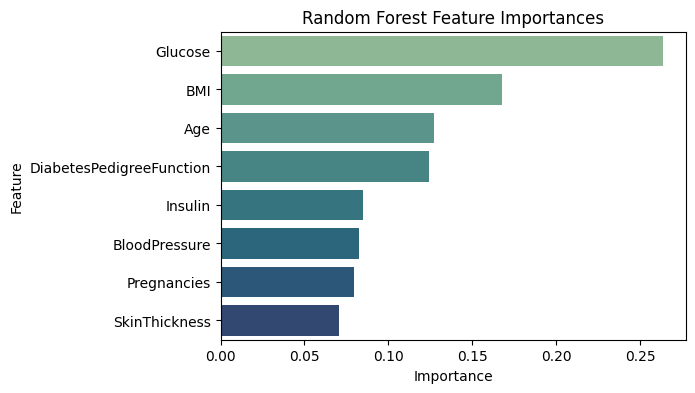

In [16]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Train Random Forest to compute Gini feature importances
rf = RandomForestClassifier(random_state=42)
rf.fit(X, pima_df['Outcome']) # Random Forest is scale invariant; raw values are suitable

# Plot feature importances
importances = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values(by='Importance', ascending=False)
print("24eu02032 Random Forest Feature Importances:\n", importances)

plt.figure(figsize=(6, 4))
sns.barplot(data=importances, x='Importance', y='Feature', palette='crest')
plt.title("Random Forest Feature Importances")
plt.show()


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Split dataset into training and test sets
X_train, X_test, y_train_p, y_test_p = train_test_split(X, pima_df['Outcome'], test_size=0.3, random_state=42)

# Model 1: Train on all 8 features
rf_full = RandomForestClassifier(random_state=42)
rf_full.fit(X_train, y_train_p)
preds_full = rf_full.predict(X_test)

# Model 2: Train on only the top 4 features identified by Random Forest
top_4_cols = importances.head(4)['Feature'].tolist()
X_train_sub = X_train[top_4_cols]
X_test_sub = X_test[top_4_cols]

rf_sub = RandomForestClassifier(random_state=42)
rf_sub.fit(X_train_sub, y_train_p)
preds_sub = rf_sub.predict(X_test_sub)

print("--- CLASSIFICATION REPORT: ALL FEATURES (8 features) ---")
print(classification_report(y_test_p, preds_full))

print("\n--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 features) ---")
print(classification_report(y_test_p, preds_sub))


--- CLASSIFICATION REPORT: ALL FEATURES (8 features) ---
              precision    recall  f1-score   support

           0       0.82      0.79      0.81       151
           1       0.63      0.66      0.65        80

    accuracy                           0.75       231
   macro avg       0.72      0.73      0.73       231
weighted avg       0.75      0.75      0.75       231


--- CLASSIFICATION REPORT: FEATURE-SELECTED SUBSET (Top 4 features) ---
              precision    recall  f1-score   support

           0       0.82      0.76      0.79       151
           1       0.60      0.68      0.64        80

    accuracy                           0.73       231
   macro avg       0.71      0.72      0.71       231
weighted avg       0.74      0.73      0.73       231



In [18]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA

# Load dataset
df = sns.load_dataset("titanic")

# Handle missing values
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

# Remove columns
df = df.drop(columns=["deck"])

# Remove remaining missing values
df = df.dropna()

# Encode ALL categorical columns automatically
le = LabelEncoder()

for col in df.select_dtypes(include=["object", "category", "bool"]).columns:
    df[col] = le.fit_transform(df[col].astype(str))

# Features and target
X = df.drop("survived", axis=1)
y = df["survived"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Standardization
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# PCA
pca = PCA(n_components=5)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nPreprocessing Completed Successfully")

Training Shape : (712, 5)
Testing Shape  : (179, 5)

Explained Variance Ratio:
[0.27318119 0.20023985 0.14519481 0.14208932 0.0713897 ]

Preprocessing Completed Successfully
